## Задание Pro



1. Выберите 10 самых красивых по вашем мнению пятерок в тренировочной выборке mnist.
2. Создайте датасет, где объекты – это все пятерки из тренировочной части mnist, а метки – это случайные пятерки из "красивого" набора.
3. Создайте автокодировщик и проверьте, совпадают ли у него размеры выхода и входа.
4. Обучите автокодировщик.
5. Добейтесь ошибки MSE на тренировочной выборке **<0.05**.
6. Посмотрите, как выглядят пятерки из тестовой выборки после обученного автокодировщика.

## **Импорт библиотек**

In [1]:
# Для операций с тензорами
import numpy as np

# Для отрисвоки
import matplotlib.pyplot as plt

# Для создания модели
from tensorflow.keras.models import Model

# Необходимые слои
from tensorflow.keras.layers import Input, Conv2DTranspose, MaxPooling2D, Conv2D, BatchNormalization

# Слои для латентного пространства модели
from tensorflow.keras.layers import Flatten, Reshape, Dense

# Оптимизатор
from tensorflow.keras.optimizers import Adam

# Для загрузки базы
from tensorflow.keras.datasets import mnist

## **Загрузка данных**

In [2]:

(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## **Нормализация данных**

In [3]:

X_train = X_train.astype('float32')/255.
X_test = X_test.astype('float32')/255.

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (60000, 28, 28)
X_test shape: (10000, 28, 28)


## **Приведение формы к удобной для обработки в Keras**

In [4]:

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)


## **Отбор пятёрок**

In [12]:

mask = y_train == 5
X_train = X_train[mask]
y_train = y_train[mask]

print(y_train)
print(y_train.shape)

[5 5 5 ... 5 5 5]
(5421,)


In [13]:
mask = y_test == 5
X_test = X_test[mask]
y_test = y_test[mask]

print(y_test)
print(y_test.shape)

[5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 

## **Отбор красивых пятерок**

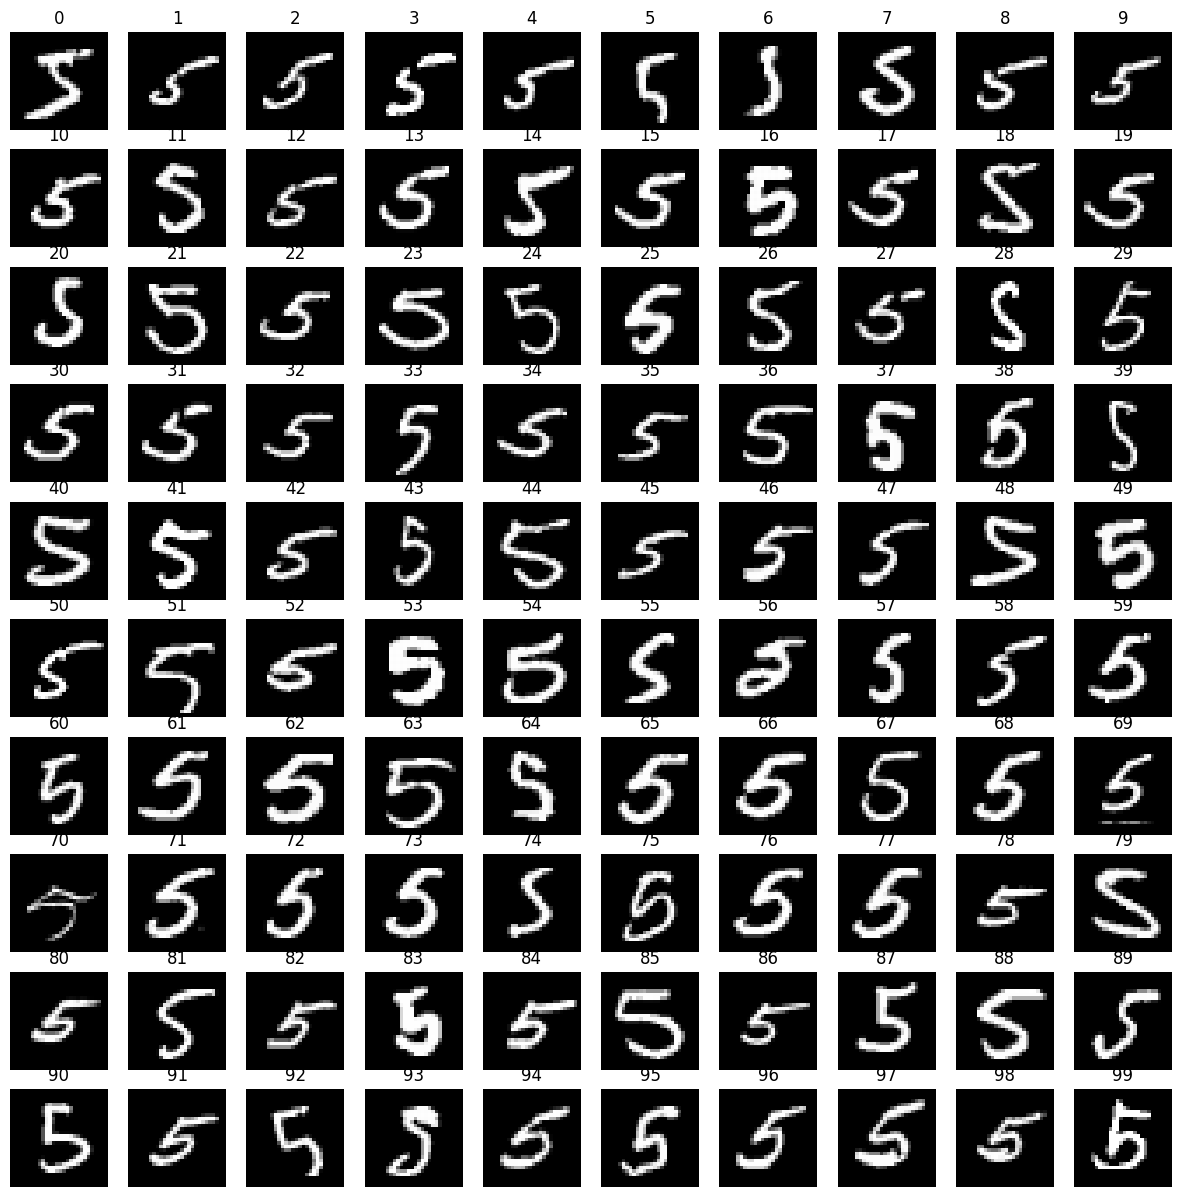

In [14]:

plt.figure(figsize=(15, 15))

for i in range(100):
    plt.subplot(10, 10, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(str(i))
    plt.axis('off')

plt.show()

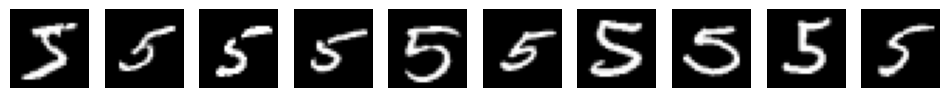

In [15]:
beautiful_idx = [0, 2, 3, 8, 63, 91, 40, 23, 87, 47]

best_fives = X_train[beautiful_idx]

plt.figure(figsize=(12, 3))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(best_fives[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.show()

In [38]:
random_idx_train = np.random.randint(0, len(best_fives), size=len(X_train))

random_idx_test = np.random.randint(0, len(best_fives), size=len(X_test))

X_train = X_train
Y_train = best_fives[random_idx_train]

X_test = X_test
Y_test = best_fives[random_idx_test]

print(X_train.shape)
print(Y_train.shape)

print(X_test.shape)
print(Y_test.shape)

(5421, 28, 28, 1)
(5421, 28, 28, 1)
(892, 28, 28, 1)
(892, 28, 28, 1)


## **Создание и обучение модели**

In [39]:
input_img = Input(shape=(28, 28, 1))

# Encoder слой
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Flatten()(x)
latent = Dense(64, activation='relu')(x)

# Decoder слой
x = Dense(7 * 7 * 64, activation='relu')(latent)
x = Reshape((7, 7, 64))(x)

x = Conv2DTranspose(64, (3, 3), strides=2, activation='relu', padding='same')(x)
x = BatchNormalization()(x)

x = Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x)
x = BatchNormalization()(x)

output_img = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, output_img)

autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

autoencoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3136)           │       203,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 479,873 (1.83 MB)

 Trainable params: 479,489 (1.83 MB)

 Non-trainable params: 384 (1.50 KB)

In [40]:
print("Input shape:", autoencoder.input_shape)
print("Output shape:", autoencoder.output_shape)

Input shape: (None, 28, 28, 1)
Output shape: (None, 28, 28, 1)


In [42]:
history = autoencoder.fit(
    X_train,
    Y_train,
    epochs=30,
    batch_size=128,
    validation_data=(X_test,Y_test),
    shuffle=True
)

Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 0.1169 - val_loss: 0.1143
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0785 - val_loss: 0.0945
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0768 - val_loss: 0.0935
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0764 - val_loss: 0.0954
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0756 - val_loss: 0.0970
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0752 - val_loss: 0.0986
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0746 - val_loss: 0.1003
Epoch 8/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0742 - val_loss: 0.1000
Epoch 9/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0740 - val_loss: 0.0988
Epoch 10/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0730 - val_loss: 0.0989
Epoch 11/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0697 - val_loss: 0.0906
Epoch 12/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0

In [43]:
final_mse = history.history['loss'][-1]
print("Final MSE:", final_mse)

Final MSE: 0.007652913220226765


## **Визуализация пятерок из тестовой выборки после автокодировщика**

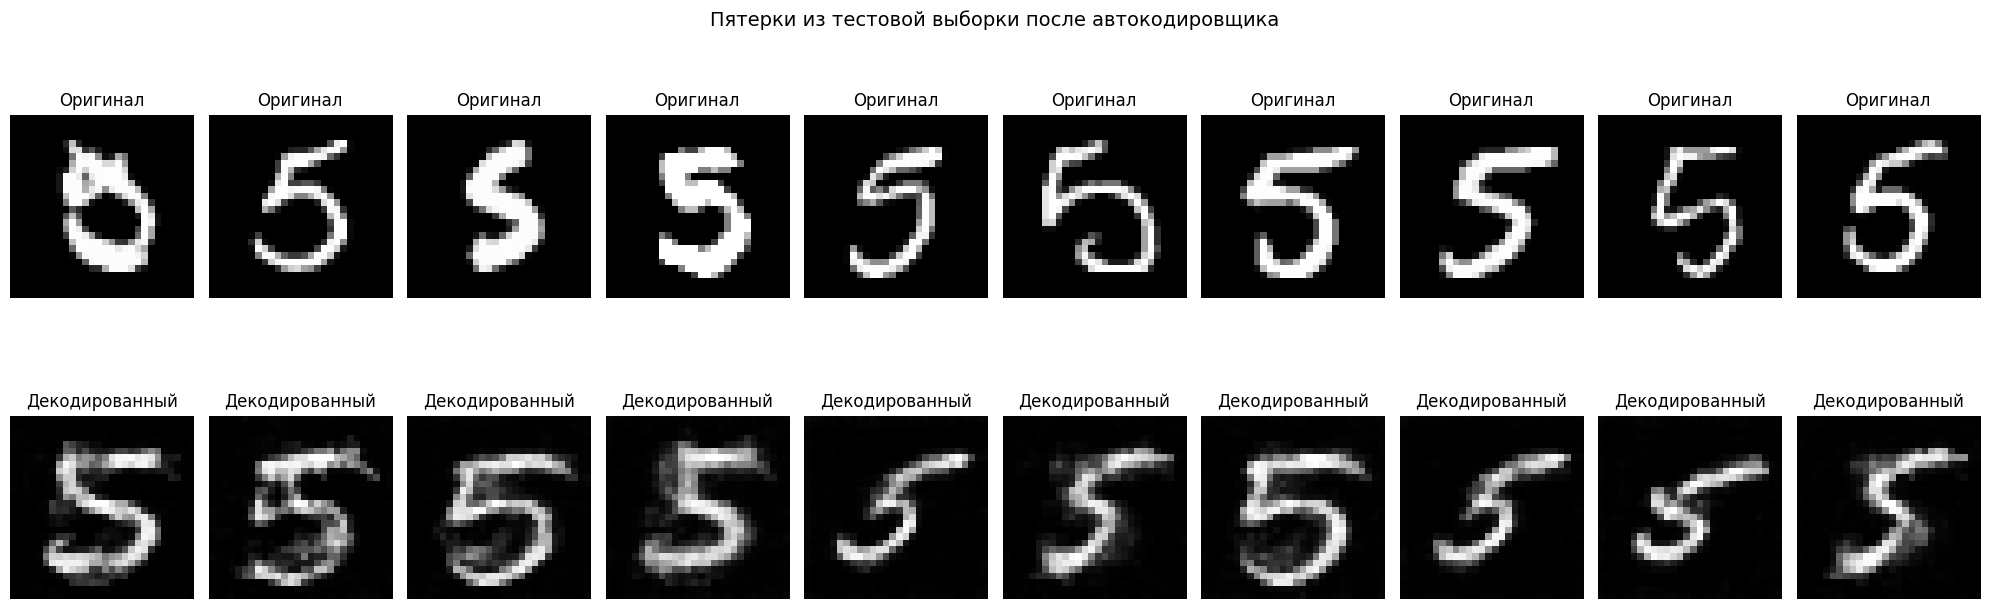

In [44]:

test_pred = autoencoder.predict(X_test, verbose=0)

plt.figure(figsize=(20, 10))
n = 10

for i in range(n):
    idx = np.random.randint(0, len(X_test))


    plt.subplot(3, n, i+1)
    plt.imshow(X_test[idx].squeeze(), cmap='gray')
    plt.title(f'Оригинал')
    plt.axis('off')


    plt.subplot(3, n, i+1+n)
    plt.imshow(test_pred[idx].squeeze(), cmap='gray')
    plt.title(f'Декодированный')
    plt.axis('off')

plt.suptitle('Пятерки из тестовой выборки после автокодировщика', fontsize=14)
plt.tight_layout()
plt.show()
